# Part 3 Supervised Machine Learning

This notebook develops classification and regression models using the cleaned and feature-engineered Metro Interstate Traffic Volume dataset produced in Part 2.

The classification task uses a documented proxy risk label because no accident dataset was supplied. This proxy demonstrates the classification workflow only and must not be interpreted as predicting actual accidents.

The regression task predicts hourly traffic volume.

In [1]:
import sys
import sklearn

print("Executable:", sys.executable)
print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)

Executable: /usr/local/bin/python3
Python: 3.13.7 (v3.13.7:bcee1c32211, Aug 14 2025, 19:10:51) [Clang 16.0.0 (clang-1600.0.26.6)]
scikit-learn: 1.9.1


In [2]:
from pathlib import Path
import logging
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [3]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT.parent / "part2_python" / "data" / "processed" / "traffic_features.csv"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
LOG_PATH = PROJECT_ROOT / "part3.log"

MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
    handlers=[
        logging.FileHandler(LOG_PATH, mode="a"),
        logging.StreamHandler(sys.stdout),
    ],
)

LOGGER = logging.getLogger(__name__)

LOGGER.info("Supervised modelling notebook started")
print(DATA_PATH)

2026-09-25 01:19:52,504 | INFO | __main__ | Supervised modelling notebook started
/Users/misatoniwa/Downloads/smart-city-traffic-capstone/part2_python/data/processed/traffic_features.csv


In [4]:
try:
    data = pd.read_csv(DATA_PATH)
except FileNotFoundError as exc:
    LOGGER.error("Feature dataset was not found at %s", DATA_PATH)
    raise FileNotFoundError(
        "Run the Part 2 pipeline and feature-engineering script first."
    ) from exc
except pd.errors.ParserError as exc:
    LOGGER.error("Feature dataset could not be parsed: %s", exc)
    raise

LOGGER.info(
    "Loaded feature dataset with %d rows and %d columns",
    data.shape[0],
    data.shape[1],
)

print("Dataset shape:", data.shape)
data.head()

2026-09-25 01:19:52,601 | INFO | __main__ | Loaded feature dataset with 48187 rows and 34 columns
Dataset shape: (48187, 34)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_description,date_time,traffic_volume,hour,day_of_week,...,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm
0,No Holiday,288.28,0.0,0.0,40,scattered clouds,2012-10-02 09:00:00,5545,9,1,...,1,0,0,0,0,0,0,0,0,0
1,No Holiday,289.36,0.0,0.0,75,broken clouds,2012-10-02 10:00:00,4516,10,1,...,1,0,0,0,0,0,0,0,0,0
2,No Holiday,289.58,0.0,0.0,90,overcast clouds,2012-10-02 11:00:00,4767,11,1,...,1,0,0,0,0,0,0,0,0,0
3,No Holiday,290.13,0.0,0.0,90,overcast clouds,2012-10-02 12:00:00,5026,12,1,...,1,0,0,0,0,0,0,0,0,0
4,No Holiday,291.14,0.0,0.0,75,broken clouds,2012-10-02 13:00:00,4918,13,1,...,1,0,0,0,0,0,0,0,0,0


## Feature preparation and proxy risk label

The existing Part 2 features are extended with cyclical encodings of the day of the week. The classification target is a documented proxy because no accident dataset was supplied.

A record is labelled high risk when High or Severe congestion occurs together with severe or low-visibility weather. This label demonstrates a classification workflow only and does not represent actual accident likelihood.

In [5]:
 # Add cyclical day-of-week features required by the instructions
data["day_of_week_sin"] = np.sin(
    2 * np.pi * data["day_of_week"] / 7
)
data["day_of_week_cos"] = np.cos(
    2 * np.pi * data["day_of_week"] / 7
)

# Weather categories treated as severe or low visibility
risky_weather_columns = [
    "weather_main_Thunderstorm",
    "weather_main_Snow",
    "weather_main_Squall",
    "weather_main_Fog",
    "weather_main_Mist",
    "weather_main_Haze",
    "weather_main_Smoke",
]

# Keep only columns that actually exist
available_risky_weather = [
    column for column in risky_weather_columns
    if column in data.columns
]

data["is_risky_weather"] = (
    data[available_risky_weather].max(axis=1).astype(int)
)

high_congestion = data["congestion_quartile"].isin(
    ["High", "Severe"]
)

data["high_risk"] = (
    high_congestion & data["is_risky_weather"].eq(1)
).astype(int)

LOGGER.info(
    "Created proxy risk label using %d risky-weather columns",
    len(available_risky_weather),
)

print("Risky-weather columns used:")
print(available_risky_weather)

print("\nProxy risk-label counts:")
print(data["high_risk"].value_counts())

print("\nProxy risk-label percentages:")
print(
    data["high_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

2026-09-25 01:19:52,624 | INFO | __main__ | Created proxy risk label using 7 risky-weather columns
Risky-weather columns used:
['weather_main_Thunderstorm', 'weather_main_Snow', 'weather_main_Squall', 'weather_main_Fog', 'weather_main_Mist', 'weather_main_Haze', 'weather_main_Smoke']

Proxy risk-label counts:
high_risk
0    42749
1     5438
Name: count, dtype: int64

Proxy risk-label percentages:
high_risk
0    88.71
1    11.29
Name: proportion, dtype: float64


## Classification models

Two classification algorithms are compared:

1. Logistic Regression as the interpretable baseline.
2. Random Forest as the tree-based ensemble.

Traffic volume and congestion category are excluded from the predictors because they were used to construct the proxy target. Including them would create target leakage.

In [6]:
weather_features = sorted(
    column for column in data.columns
    if column.startswith("weather_main_")
)

classification_features = [
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "is_holiday",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "day_of_week_sin",
    "day_of_week_cos",
    "month_sin",
    "month_cos",
] + weather_features

X_classification = data[classification_features]
y_classification = data["high_risk"]

X_class_train, X_class_test, y_class_train, y_class_test = (
    train_test_split(
        X_classification,
        y_classification,
        test_size=0.20,
        random_state=42,
        stratify=y_classification,
    )
)

LOGGER.info(
    "Created stratified classification split with %d training and %d test records",
    len(X_class_train),
    len(X_class_test),
)

print("Number of classification features:", len(classification_features))
print("Training records:", len(X_class_train))
print("Test records:", len(X_class_test))
print(
    "High-risk percentage in test data:",
    round(y_class_test.mean() * 100, 2),
)

2026-09-25 01:19:52,667 | INFO | __main__ | Created stratified classification split with 38549 training and 9638 test records
Number of classification features: 23
Training records: 38549
Test records: 9638
High-risk percentage in test data: 11.29


In [7]:
classification_models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=42,
                ),
            ),
        ]
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
}

classification_results = []
classification_probabilities = {}

for model_name, model in classification_models.items():
    LOGGER.info("Training classification model: %s", model_name)

    model.fit(X_class_train, y_class_train)

    predictions = model.predict(X_class_test)
    probabilities = model.predict_proba(X_class_test)[:, 1]

    classification_probabilities[model_name] = probabilities

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_class_test, predictions),
        "Precision": precision_score(
            y_class_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_class_test, predictions, zero_division=0
        ),
        "F1": f1_score(
            y_class_test, predictions, zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_class_test, probabilities
        ),
    }

    classification_results.append(metrics)

    LOGGER.info(
        "%s completed with ROC AUC %.4f",
        model_name,
        metrics["ROC_AUC"],
    )

classification_results_df = (
    pd.DataFrame(classification_results)
    .sort_values("ROC_AUC", ascending=False)
    .reset_index(drop=True)
)

classification_results_df.round(4)

2026-09-25 01:19:52,675 | INFO | __main__ | Training classification model: Logistic Regression
2026-09-25 01:19:52,736 | INFO | __main__ | Logistic Regression completed with ROC AUC 0.9937
2026-09-25 01:19:52,737 | INFO | __main__ | Training classification model: Random Forest
2026-09-25 01:19:53,396 | INFO | __main__ | Random Forest completed with ROC AUC 0.9970


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.9847,0.8918,0.9844,0.9358,0.9970
1,Logistic Regression,0.9660,0.7766,0.9807,0.8668,0.9937


### Classification interpretation

The Random Forest achieved the strongest overall performance, including the highest accuracy, precision, F1-score and ROC AUC. Logistic Regression produced slightly higher recall but lower precision, indicating that it identified most high-risk proxy records at the cost of more false-positive classifications.

These results evaluate the reproduction of a rule-based proxy label rather than the prediction of real accidents. They should therefore not be interpreted as evidence of real-world accident-risk performance.

2026-09-25 01:19:53,535 | INFO | __main__ | Saved best classifier Random Forest to /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/models/best_risk_classifier.joblib


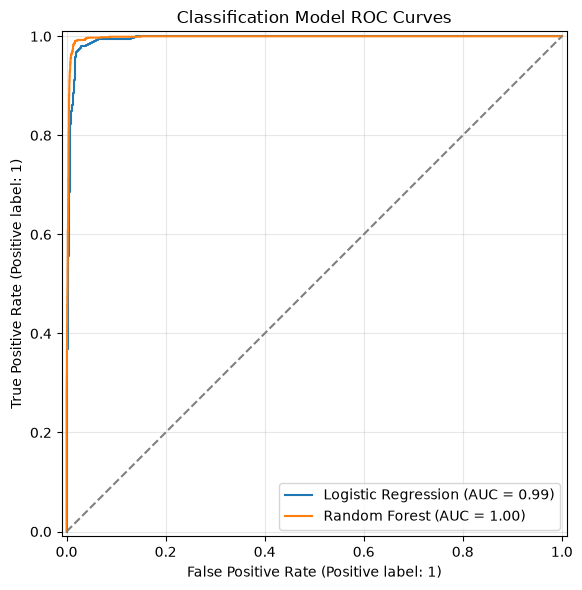

Best classifier: Random Forest
Saved model: /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/models/best_risk_classifier.joblib
Saved results: /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/reports/classification_model_results.csv
Saved ROC figure: /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/reports/classification_roc_curves.png


In [8]:
# Save the classification comparison
classification_results_path = (
    REPORTS_DIR / "classification_model_results.csv"
)
classification_results_df.to_csv(
    classification_results_path,
    index=False,
)

# Select and save the best classifier by ROC AUC
best_classifier_name = classification_results_df.loc[0, "Model"]
best_classifier = classification_models[best_classifier_name]

classifier_package = {
    "model": best_classifier,
    "features": classification_features,
    "target": "high_risk",
    "proxy_definition": (
        "High or Severe congestion combined with severe "
        "or low-visibility weather"
    ),
}

classifier_path = MODELS_DIR / "best_risk_classifier.joblib"
joblib.dump(
    classifier_package,
    classifier_path,
    compress=3,
)

LOGGER.info(
    "Saved best classifier %s to %s",
    best_classifier_name,
    classifier_path,
)

# Create and save the ROC comparison
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, probabilities in classification_probabilities.items():
    RocCurveDisplay.from_predictions(
        y_class_test,
        probabilities,
        name=model_name,
        ax=ax,
    )

ax.plot([0, 1], [0, 1], linestyle="--", color="grey")
ax.set_title("Classification Model ROC Curves")
ax.grid(alpha=0.3)

roc_path = REPORTS_DIR / "classification_roc_curves.png"
fig.tight_layout()
fig.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()

print("Best classifier:", best_classifier_name)
print("Saved model:", classifier_path)
print("Saved results:", classification_results_path)
print("Saved ROC figure:", roc_path)

## Regression models

The regression task predicts hourly traffic volume using the same common feature set used for classification. Linear Regression provides an interpretable baseline, while Random Forest Regression captures non-linear relationships between time, weather and traffic demand.

Performance is compared using mean absolute error and R-squared.

In [9]:
X_regression = data[classification_features]
y_regression = data["traffic_volume"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = (
    train_test_split(
        X_regression,
        y_regression,
        test_size=0.20,
        random_state=42,
    )
)

LOGGER.info(
    "Created regression split with %d training and %d test records",
    len(X_reg_train),
    len(X_reg_test),
)

print("Regression features:", len(classification_features))
print("Training records:", len(X_reg_train))
print("Test records:", len(X_reg_test))

2026-09-25 01:19:53,787 | INFO | __main__ | Created regression split with 38549 training and 9638 test records
Regression features: 23
Training records: 38549
Test records: 9638


In [10]:
regression_models = {
    "Linear Regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", LinearRegression()),
        ]
    ),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=200,
        max_depth=18,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    ),
}

regression_results = []
regression_predictions = {}

for model_name, model in regression_models.items():
    LOGGER.info("Training regression model: %s", model_name)

    model.fit(X_reg_train, y_reg_train)
    predictions = model.predict(X_reg_test)

    regression_predictions[model_name] = predictions

    metrics = {
        "Model": model_name,
        "MAE": mean_absolute_error(
            y_reg_test, predictions
        ),
        "R2": r2_score(
            y_reg_test, predictions
        ),
    }

    regression_results.append(metrics)

    LOGGER.info(
        "%s completed with MAE %.2f and R2 %.4f",
        model_name,
        metrics["MAE"],
        metrics["R2"],
    )

regression_results_df = (
    pd.DataFrame(regression_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

regression_results_df.round(4)

2026-09-25 01:19:53,793 | INFO | __main__ | Training regression model: Linear Regression
2026-09-25 01:19:53,825 | INFO | __main__ | Linear Regression completed with MAE 832.91 and R2 0.7099
2026-09-25 01:19:53,826 | INFO | __main__ | Training regression model: Random Forest Regressor
2026-09-25 01:19:56,461 | INFO | __main__ | Random Forest Regressor completed with MAE 244.04 and R2 0.9538


,Model,MAE,R2
0,Random Forest Regressor,244.0422,0.9538
1,Linear Regression,832.9087,0.7099


In [11]:
best_regression_name = regression_results_df.iloc[0]["Model"]
best_regression_model = regression_models[best_regression_name]

regression_model_path = MODELS_DIR / "best_traffic_regressor.joblib"
regression_results_path = REPORTS_DIR / "regression_model_results.csv"

joblib.dump(
    best_regression_model,
    regression_model_path,
    compress=3,
)
regression_results_df.to_csv(regression_results_path, index=False)

print(f"Best regressor: {best_regression_name}")
print(f"Saved model: {regression_model_path}")
print(f"Saved results: {regression_results_path}")

LOGGER.info(
    "Saved best regression model %s to %s",
    best_regression_name,
    regression_model_path,
)

Best regressor: Random Forest Regressor
Saved model: /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/models/best_traffic_regressor.joblib
Saved results: /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/reports/regression_model_results.csv
2026-09-25 01:19:58,748 | INFO | __main__ | Saved best regression model Random Forest Regressor to /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/models/best_traffic_regressor.joblib


### Regression interpretation

The Random Forest Regressor substantially outperformed Linear Regression. It achieved a mean absolute error of approximately 244 vehicles per hour and an R-squared value of 0.9538, compared with a mean absolute error of approximately 833 vehicles per hour and an R-squared value of 0.7100 for Linear Regression.

This indicates that the Random Forest captured the non-linear relationships between time, weather and traffic demand more effectively. Its R-squared value suggests that approximately 95.38% of the variation in hourly traffic volume was explained in the test data. The lower error also means that its predictions differed from the observed traffic volumes by approximately 244 vehicles per hour on average.

The results support the earlier conclusion that recurring time-related patterns are strong predictors of traffic demand. However, performance was measured using a random train-test split from one historical traffic-monitoring location, so the model should be validated using later time periods and other locations before operational deployment.